# Mini-GPT Decoder with Shakespeare Text

In [2]:
import numpy as np
import tensorflow as tf

import urllib.request
url = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
urllib.request.urlretrieve(url, 'shakespeare.txt')
with open('shakespeare.txt', 'r') as f:
    text = f.read()
print(text[:500])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


1. Embedding

In [ ]:
#encoding using dicts
data = list(text.lower())
vocab = sorted(set(data))
word_to_idx = {char:idx for idx, char in enumerate(vocab)}
idx_to_word = {idx:char for idx, char in enumerate(vocab)}
encoderr = [word_to_idx[char] for char in data]

seq_length = 32
X, y = [], []

#sliding context window to make X,y
for i in range(len(encoderr) - seq_length):
    X.append(encoderr[i : i + seq_length])
    y.append(encoderr[i + 1 : i + seq_length + 1])
X,y = np.array(X), np.array(y)


split = int(len(encoderr) * 0.8)
train_data = encoderr[:split]
val_data = encoderr[split:]

def make_windows(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+1:i+seq_length+1])
    return np.array(X), np.array(y)

X_train, y_train = make_windows(train_data, 32)
X_val, y_val = make_windows(val_data, 32)

X_train = X_train[:100000]
y_train = y_train[:100000]
X_val = X_val[:100000]
y_val = y_val[:100000]


X_train = np.array(X_train, dtype=np.int32)
y_train = np.array(y_train, dtype=np.int32)
X_val = np.array(X_val, dtype=np.int32)
y_val = np.array(y_val, dtype=np.int32)
print(X.shape,y.shape)
print(X_train.shape,y_train.shape)

(1115362, 32) (1115362, 32)
(100000, 32) (100000, 32)


In [ ]:
import tensorflow as tf

vocab_size = len(vocab)
embed_dim = 64
seq_length = 32
#embedding including position and token data
class EmbeddingBlock(tf.keras.layers.Layer):
    def __init__(self, vocab_size, embed_dim, seq_length):
        super().__init__()
        self.tok = tf.keras.layers.Embedding(vocab_size,embed_dim)
        self.pos = tf.keras.layers.Embedding(seq_length,embed_dim)
    
    def call(self, x):
        seq_length = tf.shape(x)[1]
        positions = tf.range(seq_length)
        return self.tok(x) + self.pos(positions)
        pass
        

2. SingleHeadAttention

In [ ]:
class SingleHead(tf.keras.layers.Layer):
    def __init__(self, embed_dim, head_dim):
        super().__init__()
        self.head_dim = head_dim
        # three linear projections: Wq, Wk, Wv
        # each projects from embed_dim to head_dim
        self.Wq = tf.keras.layers.Dense(head_dim,use_bias=False)
        self.Wk = tf.keras.layers.Dense(head_dim,use_bias=False)
        self.Wv = tf.keras.layers.Dense(head_dim,use_bias=False)
    
      
    def call(self, x):
        # x shape: (batch, seq, embed_dim)
        # 1. project x into Q, K, V
        # 2. scores = Q @ K^T / sqrt(head_dim)
        # 3. causal mask
        # 4. softmax
        # 5. output = weights @ V
        Q = self.Wq(x)
        K = self.Wk(x)
        V = self.Wv(x)
        scores = Q @ tf.transpose(K, perm=[0, 2, 1]) / tf.math.sqrt(tf.cast(self.head_dim, tf.float32))
        # creates a lower triangular matrix of ones
        seq_length = tf.shape(x)[1]
        mask = tf.linalg.band_part(tf.ones((seq_length, seq_length)), -1, 0)
        # then convert: 1 where allowed, 0 where blocked -> invert and scale
        mask = (1 - mask) * -1e9
        scores = scores + mask
        scores = tf.nn.softmax(scores, axis=-1)
        output = scores @ V
        return output,scores
        pass

3.MultiHeadAttention

In [ ]:
class MultiHeadAttention(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        
        self.head_dim = embed_dim // num_heads
        assert embed_dim % num_heads == 0, "embed_dim must be divisible by num_heads"
        
        self.heads = [SingleHead(embed_dim, self.head_dim) for _ in range(num_heads)]
        self.proj = tf.keras.layers.Dense(embed_dim, use_bias=False)
    
    def call(self, x):
        # run each head, get outputs and weights separately
        outputs, weights = zip(*[head(x) for head in self.heads])
        # concat all head outputs: 4 x (batch, seq, 16) → (batch, seq, 64)
        concat = tf.concat(outputs, axis=-1)
        # mix information across heads
        out = self.proj(concat)
        # weights is a tuple of 4 tensors, each (batch, seq, seq)
        return out, weights

In [ ]:
class GPTBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        self.attn = MultiHeadAttention(embed_dim, num_heads)
        self.ff1 = tf.keras.layers.Dense(4 * embed_dim, activation='relu')
        self.ff2 = tf.keras.layers.Dense(embed_dim)
        self.norm1 = tf.keras.layers.LayerNormalization()
        self.norm2 = tf.keras.layers.LayerNormalization()
        self.drop1 = tf.keras.layers.Dropout(0.2)
        self.drop2 = tf.keras.layers.Dropout(0.2)

    def call(self, x):
        attn_out, weights = self.attn(x)
        x = self.norm1(x + self.drop1(attn_out))
        ff_out = self.ff2(self.drop2(self.ff1(x)))
        x = self.norm2(x + ff_out)
        return x, weights

In [ ]:
class MiniGPT(tf.keras.Model):
    def __init__(self, vocab_size, embed_dim, seq_length, num_heads, num_blocks):
        super().__init__()
        self.embed = EmbeddingBlock(vocab_size, embed_dim, seq_length)
        self.blocks = [GPTBlock(embed_dim, num_heads) for _ in range(num_blocks)]
        self.head = tf.keras.layers.Dense(vocab_size)  # no softmax — use from_logits

    def call(self, x):
        x = self.embed(x)
        all_weights = []
        for block in self.blocks:
            x, weights = block(x)
            all_weights.append(weights)  # (num_blocks, num_heads, batch, seq, seq)
        logits = self.head(x)
        return logits, all_weights

In [ ]:
model = MiniGPT(
    vocab_size=len(vocab),
    embed_dim=64,
    seq_length=32,
    num_heads=4,
    num_blocks=2
)

optimizer = tf.keras.optimizers.Adam(learning_rate=3e-4)
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

In [ ]:
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_dataset = train_dataset.shuffle(10000).batch(512).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_dataset = val_dataset.batch(512).prefetch(tf.data.AUTOTUNE)

train_losses, val_losses = [], []

@tf.function
def train_step(xb, yb):
    with tf.GradientTape() as tape:
        logits, _ = model(xb, training=True)
        loss = loss_fn(yb, logits)
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss

@tf.function
def val_step(xb, yb):
    logits, _ = model(xb, training=False)
    return loss_fn(yb, logits)

EPOCHS = 10
for epoch in range(EPOCHS):
    batch_losses = []
    for xb, yb in train_dataset:
        batch_losses.append(train_step(xb, yb).numpy())
    
    val_batch_losses = []
    for xb, yb in val_dataset:
        val_batch_losses.append(val_step(xb, yb).numpy())
    
    tl = np.mean(batch_losses)
    vl = np.mean(val_batch_losses)
    train_losses.append(tl)
    val_losses.append(vl)
    print(f"Epoch {epoch+1} | train loss: {tl:.4f} | val loss: {vl:.4f} | "
          f"train ppl: {np.exp(tl):.2f} | val ppl: {np.exp(vl):.2f}") 

Epoch 1 | train loss: 2.6167 | val loss: 2.4782 | train ppl: 13.69 | val ppl: 11.92
Epoch 2 | train loss: 2.2911 | val loss: 2.3154 | train ppl: 9.89 | val ppl: 10.13
Epoch 3 | train loss: 2.1335 | val loss: 2.2271 | train ppl: 8.44 | val ppl: 9.27
Epoch 4 | train loss: 2.0261 | val loss: 2.1807 | train ppl: 7.58 | val ppl: 8.85
Epoch 5 | train loss: 1.9510 | val loss: 2.1530 | train ppl: 7.04 | val ppl: 8.61
Epoch 6 | train loss: 1.9010 | val loss: 2.1275 | train ppl: 6.69 | val ppl: 8.39
Epoch 7 | train loss: 1.8658 | val loss: 2.1136 | train ppl: 6.46 | val ppl: 8.28
Epoch 8 | train loss: 1.8373 | val loss: 2.0972 | train ppl: 6.28 | val ppl: 8.14
Epoch 9 | train loss: 1.8145 | val loss: 2.0897 | train ppl: 6.14 | val ppl: 8.08
Epoch 10 | train loss: 1.7946 | val loss: 2.0798 | train ppl: 6.02 | val ppl: 8.00


In [ ]:
class BigramModel:
    def __init__(self, vocab_size):
        self.counts = np.zeros((vocab_size, vocab_size))

    def train(self, data):
        for i in range(len(data) - 1):
            self.counts[data[i]][data[i+1]] += 1
        self.probs = self.counts / (self.counts.sum(axis=1, keepdims=True) + 1e-9)

    def loss(self, X, y):
        total = 0
        n = 0
        for seq_x, seq_y in zip(X, y):
            for cx, cy in zip(seq_x, seq_y):
                total += -np.log(self.probs[cx][cy] + 1e-9)
                n += 1
        return total / n

bigram = BigramModel(len(vocab))
bigram.train(train_data)
bl = bigram.loss(X_val[:1000], y_val[:1000])
print(f"Bigram val loss: {bl:.4f} | ppl: {np.exp(bl):.2f}")

Bigram val loss: 2.4169 | ppl: 11.21


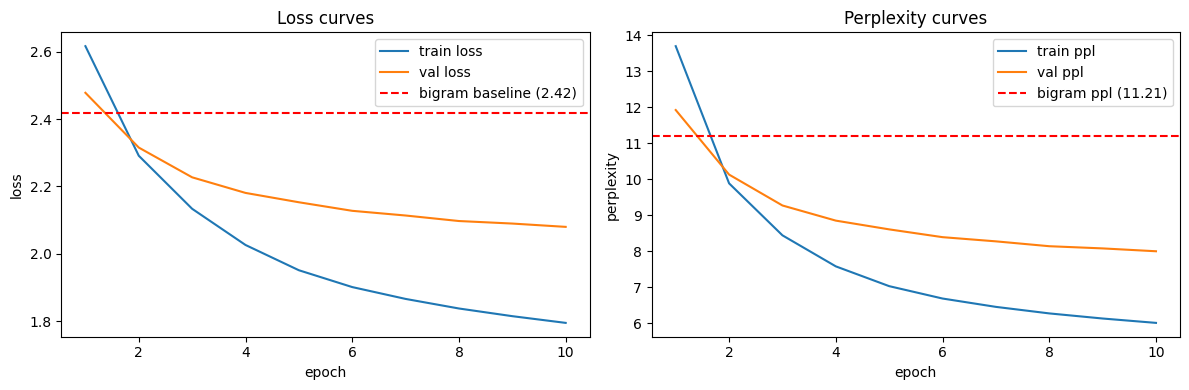

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, EPOCHS + 1)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='train loss')
plt.plot(epochs, val_losses, label='val loss')
plt.axhline(bl, color='red', linestyle='--', label=f'bigram baseline ({bl:.2f})')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.title('Loss curves')

plt.subplot(1, 2, 2)
plt.plot(epochs, np.exp(train_losses), label='train ppl')
plt.plot(epochs, np.exp(val_losses), label='val ppl')
plt.axhline(np.exp(bl), color='red', linestyle='--', label=f'bigram ppl ({np.exp(bl):.2f})')
plt.xlabel('epoch')
plt.ylabel('perplexity')
plt.legend()
plt.title('Perplexity curves')

plt.tight_layout()
plt.savefig('loss_curves.png', dpi=150)
plt.show()


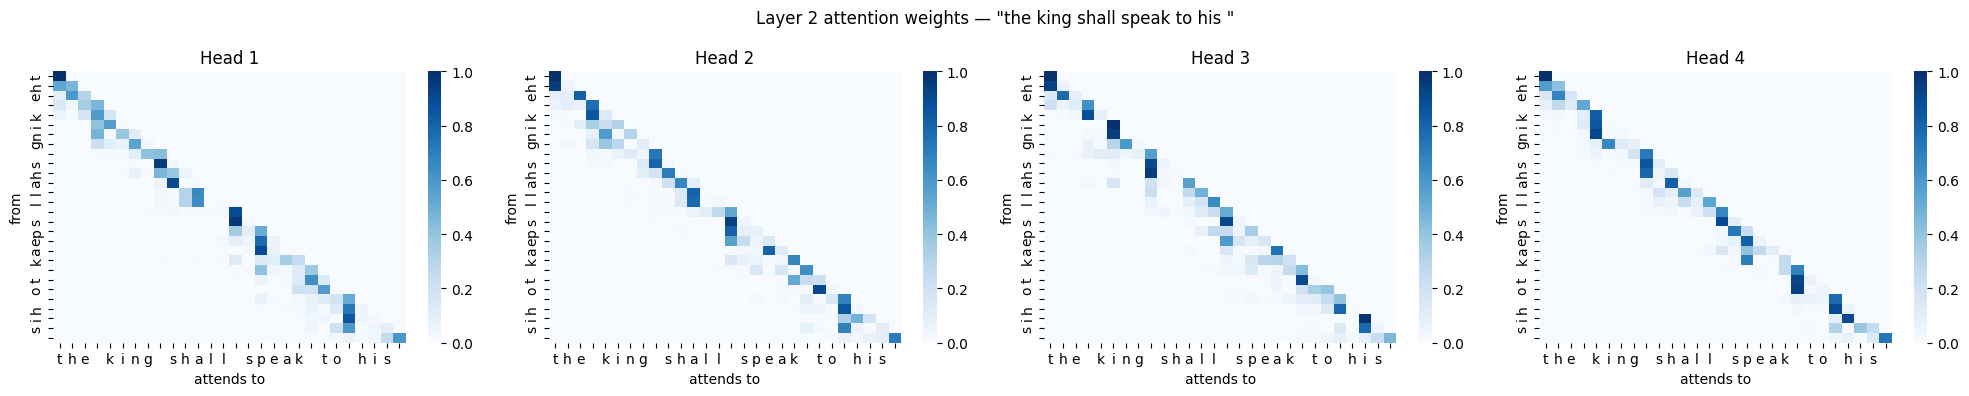

In [ ]:
import seaborn as sns

def plot_attention(text_input, model, word_to_idx, idx_to_word, layer=0):
    # encode input
    tokens = [word_to_idx[c] for c in text_input.lower()]
    x = tf.constant([tokens])                          # (1, seq)
    logits, all_weights = model(x, training=False)

    # all_weights: (num_blocks, num_heads, 1, seq, seq)
    heads = all_weights[layer]                         # tuple of 4, each (1, seq, seq)
    chars = list(text_input.lower())

    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    for h, ax in enumerate(axes):
        w = heads[h][0].numpy()                        # (seq, seq)
        sns.heatmap(w, xticklabels=chars, yticklabels=chars,
                    ax=ax, cmap='Blues', vmin=0, vmax=1)
        ax.set_title(f'Head {h+1}')
        ax.set_xlabel('attends to')
        ax.set_ylabel('from')
    plt.suptitle(f'Layer {layer+1} attention weights — "{text_input}"')
    plt.tight_layout()
    plt.savefig('attention_viz.png', dpi=150)
    plt.show()



plot_attention("the king shall speak to his ", model, word_to_idx, idx_to_word, layer=1)

In [ ]:
def generate(model, seed, length=200, temperature=0.8):
    tokens = [word_to_idx.get(c, 0) for c in seed.lower()]
    result = list(seed)
    for _ in range(length):
        x = tf.constant([tokens[-seq_length:]])        # take last 32 tokens
        logits, _ = model(x, training=False)
        next_logits = logits[0, -1, :] / temperature   # last position
        next_token = tf.random.categorical(
            tf.expand_dims(next_logits, 0), num_samples=1
        ).numpy()[0][0]
        tokens.append(next_token)
        result.append(idx_to_word[next_token])
    return ''.join(result)

print(generate(model, seed="the king ", length=300))

the king ieffer: dow,
that you the thato would! cand to speack. send to my ther
affillow, bed your had to a bemary gear wromerp,
the bead the pay hee sent that your and my stay,
their.

sicinius:
peennce falourse, tare dangues for love but the be
the he were a would, and foorn,
whe forst offers, to the goods
